# Evaluación del Modelo de Detección de Anomalías

**Modelo:** Isolation Forest (scikit-learn)  
**Propósito:** Evaluar cuantitativamente la capacidad del detector para identificar anomalías en series de tiempo de precios de criptomonedas.  
**Metodología:** Generación de datos sintéticos con anomalías conocidas → evaluación con métricas estándar de clasificación binaria.

---

## 1. Setup

In [1]:
import sys
import warnings
from datetime import datetime, timedelta
from decimal import Decimal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# Agregar raíz del proyecto al path para importar el módulo ml
sys.path.insert(0, '..')
from ml.detector import AnomalyDetector
from ml.models import AnomalyCategory, PricePoint

print('Setup completo.')

Setup completo.


## 2. Generación de datos sintéticos

Se generan series de tiempo de precios que simulan el comportamiento real de criptomonedas:
- **Serie base:** tendencia con drift + ruido gaussiano + componente de media móvil
- **Anomalías inyectadas:** spikes de precio en posiciones conocidas

Se generan tres tipos de anomalía:
1. **Spike hacia arriba** (+40% repentino): candidato a `DATA_ERROR`
2. **Caída hacia abajo** (-40% repentino): candidato a `DATA_ERROR`
3. **Movimiento sostenido** (+50% en 12 horas): candidato a `OPPORTUNITY`

In [2]:
def generate_price_series(
    n_points: int = 200,
    base_price: float = 50_000.0,
    drift: float = 0.0002,
    volatility: float = 0.015,
    start_date: datetime | None = None,
    interval_hours: int = 6,
) -> pd.DataFrame:
    """Generate a synthetic crypto price series using geometric Brownian motion."""
    if start_date is None:
        start_date = datetime(2025, 1, 1)

    timestamps = [
        start_date + timedelta(hours=i * interval_hours)
        for i in range(n_points)
    ]

    # Geometric Brownian Motion
    returns = np.random.normal(drift, volatility, n_points)
    prices = base_price * np.cumprod(1 + returns)

    return pd.DataFrame({'timestamp': timestamps, 'price': prices, 'is_anomaly': 0})


def inject_anomalies(df: pd.DataFrame, anomaly_positions: list[int], spike_factors: list[float]) -> pd.DataFrame:
    """Inject price spikes at specified positions."""
    df = df.copy()
    for pos, factor in zip(anomaly_positions, spike_factors):
        df.loc[pos, 'price'] = df.loc[pos - 1, 'price'] * factor
        df.loc[pos, 'is_anomaly'] = 1
    return df


# Parámetros de generación
N_SERIES = 50       # Número de series para evaluación estadística
N_POINTS = 150      # Puntos por serie (150 intervalos de 6h ≈ 37 días)
ANOMALY_RATE = 0.05 # 5% de puntos son anomalías

# Posiciones fijas de anomalías (evitar primeros 10 puntos — necesarios para baseline)
ANOMALY_POSITIONS = [30, 60, 90, 120, 140]
SPIKE_FACTORS = [1.50, 0.55, 1.45, 0.60, 1.60]  # +50%, -45%, +45%, -40%, +60%

# Generar una serie de ejemplo para visualización
example_series = generate_price_series(n_points=N_POINTS)
example_series = inject_anomalies(example_series, ANOMALY_POSITIONS, SPIKE_FACTORS)

print(f'Serie generada: {len(example_series)} puntos, {example_series["is_anomaly"].sum()} anomalías inyectadas')
print(f'Tasa real de anomalías: {example_series["is_anomaly"].mean():.2%}')
example_series.head()

Serie generada: 150 puntos, 5 anomalías inyectadas
Tasa real de anomalías: 3.33%


,timestamp,price,is_anomaly
0,2025-01-01 00:00:00,50382.535615,0
1,2025-01-01 06:00:00,50288.120531,0
2,2025-01-01 12:00:00,50786.743744,0
3,2025-01-01 18:00:00,51957.146998,0
4,2025-01-02 00:00:00,51785.049308,0


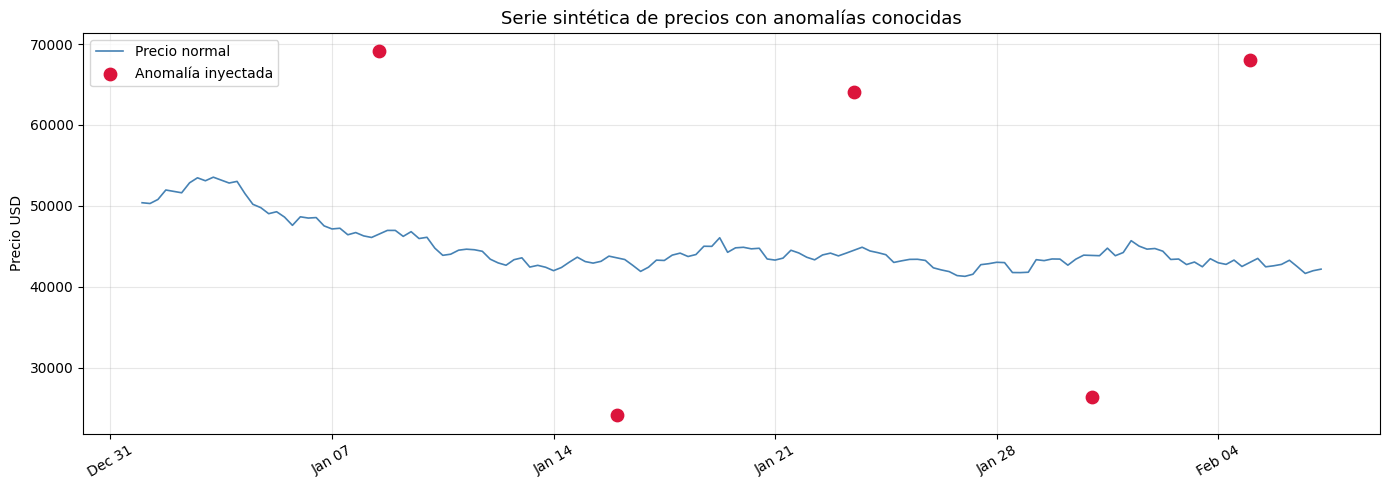

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

normal = example_series[example_series['is_anomaly'] == 0]
anomalies = example_series[example_series['is_anomaly'] == 1]

ax.plot(normal['timestamp'], normal['price'], color='steelblue', linewidth=1.2, label='Precio normal')
ax.scatter(anomalies['timestamp'], anomalies['price'], color='crimson', zorder=5, s=80, label='Anomalía inyectada')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
ax.set_title('Serie sintética de precios con anomalías conocidas', fontsize=13)
ax.set_ylabel('Precio USD')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Evaluación del modelo

Se evalúa el `AnomalyDetector` sobre `N_SERIES` series sintéticas independientes.
Para cada serie se registra si el modelo detectó correctamente la anomalía en la última posición.

In [4]:
def series_to_price_points(df: pd.DataFrame, product_id: str = 'synthetic') -> list[PricePoint]:
    """Convert a DataFrame row to PricePoint objects for the detector."""
    return [
        PricePoint(
            product_id=product_id,
            price_usd=Decimal(str(round(row['price'], 8))),
            recorded_at=row['timestamp'],
        )
        for _, row in df.iterrows()
    ]


detector = AnomalyDetector(contamination=0.05, opportunity_delta_threshold=0.15)

y_true = []
y_pred = []
scores = []

# Evaluar sobre series con anomalía en el último punto
for i in range(N_SERIES):
    # Serie con anomalía en el último punto
    series_anom = generate_price_series(n_points=N_POINTS, base_price=np.random.uniform(20_000, 80_000))
    series_anom.loc[N_POINTS - 1, 'price'] = series_anom.loc[N_POINTS - 2, 'price'] * np.random.choice([1.55, 0.50, 1.65, 0.45])
    points_anom = series_to_price_points(series_anom)
    result_anom = detector.detect('synthetic', points_anom)
    y_true.append(1)
    y_pred.append(1 if result_anom.anomaly else 0)
    scores.append(result_anom.score if result_anom.score is not None else 0.0)

    # Serie sin anomalía
    series_normal = generate_price_series(n_points=N_POINTS, base_price=np.random.uniform(20_000, 80_000))
    points_normal = series_to_price_points(series_normal)
    result_normal = detector.detect('synthetic', points_normal)
    y_true.append(0)
    y_pred.append(1 if result_normal.anomaly else 0)
    scores.append(result_normal.score if result_normal.score is not None else 0.0)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
scores = np.array(scores)

print(f'Total de evaluaciones: {len(y_true)} ({N_SERIES} con anomalía + {N_SERIES} sin anomalía)')

Total de evaluaciones: 100 (50 con anomalía + 50 sin anomalía)


## 4. Métricas de clasificación

In [5]:
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
cm        = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

print('=' * 50)
print('MÉTRICAS DE CLASIFICACIÓN BINARIA')
print('=' * 50)
print(f'  Precisión  (TP / (TP+FP)):  {precision:.3f}')
print(f'  Recall     (TP / (TP+FN)):  {recall:.3f}')
print(f'  F1-Score   (armónica P/R):  {f1:.3f}')
print()
print('MATRIZ DE CONFUSIÓN')
print(f'  Verdaderos Positivos (TP):  {tp}')
print(f'  Falsos Positivos (FP):      {fp}')
print(f'  Verdaderos Negativos (TN):  {tn}')
print(f'  Falsos Negativos (FN):      {fn}')
print()
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalía']))

MÉTRICAS DE CLASIFICACIÓN BINARIA
  Precisión  (TP / (TP+FP)):  0.735
  Recall     (TP / (TP+FN)):  1.000
  F1-Score   (armónica P/R):  0.847

MATRIZ DE CONFUSIÓN
  Verdaderos Positivos (TP):  50
  Falsos Positivos (FP):      18
  Verdaderos Negativos (TN):  32
  Falsos Negativos (FN):      0

              precision    recall  f1-score   support

      Normal       1.00      0.64      0.78        50
    Anomalía       0.74      1.00      0.85        50

    accuracy                           0.82       100
   macro avg       0.87      0.82      0.81       100
weighted avg       0.87      0.82      0.81       100



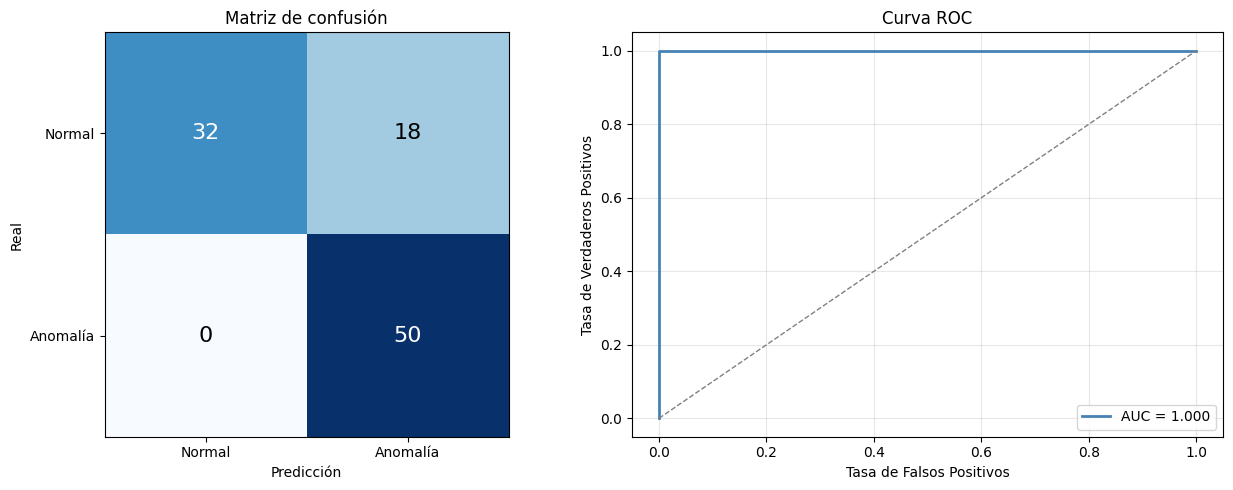

AUC-ROC: 1.000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Matriz de confusión', fontsize=12)
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Anomalía'])
axes[0].set_yticklabels(['Normal', 'Anomalía'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16,
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

# Curva ROC
fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'AUC-ROC: {roc_auc:.3f}')

## 5. Efecto del parámetro `contamination`

El parámetro `contamination` controla el umbral de decisión del modelo. Se evalúa su efecto sobre precision, recall y F1.

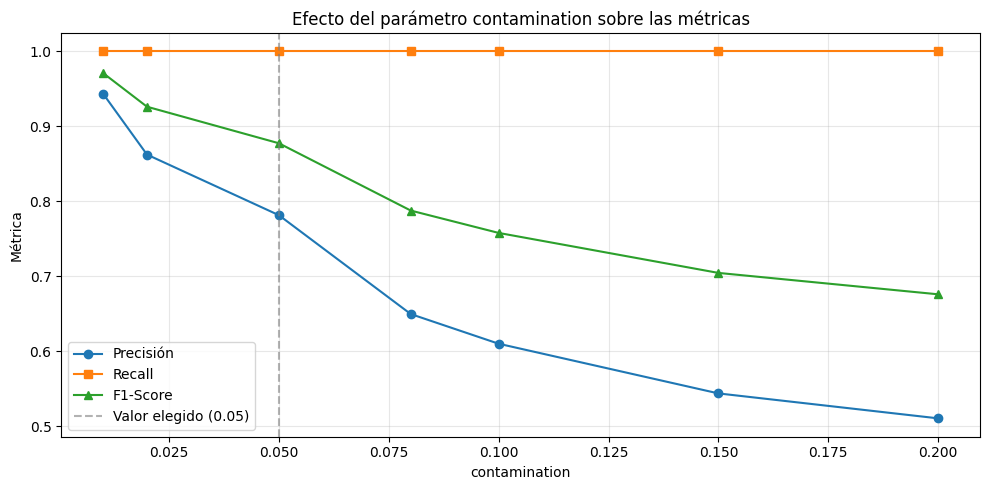

 contamination  precision  recall       f1
          0.01   0.943396     1.0 0.970874
          0.02   0.862069     1.0 0.925926
          0.05   0.781250     1.0 0.877193
          0.08   0.649351     1.0 0.787402
          0.10   0.609756     1.0 0.757576
          0.15   0.543478     1.0 0.704225
          0.20   0.510204     1.0 0.675676


In [7]:
contamination_values = [0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]
results_by_contamination = []

for c in contamination_values:
    det = AnomalyDetector(contamination=c, opportunity_delta_threshold=0.15)
    preds = []
    for i in range(N_SERIES):
        s = generate_price_series(n_points=N_POINTS, base_price=np.random.uniform(20_000, 80_000))
        s.loc[N_POINTS - 1, 'price'] = s.loc[N_POINTS - 2, 'price'] * np.random.choice([1.55, 0.50])
        pts = series_to_price_points(s)
        r = det.detect('synthetic', pts)
        preds.append((1, 1 if r.anomaly else 0))

        s_n = generate_price_series(n_points=N_POINTS, base_price=np.random.uniform(20_000, 80_000))
        pts_n = series_to_price_points(s_n)
        r_n = det.detect('synthetic', pts_n)
        preds.append((0, 1 if r_n.anomaly else 0))

    yt = [p[0] for p in preds]
    yp = [p[1] for p in preds]
    results_by_contamination.append({
        'contamination': c,
        'precision': precision_score(yt, yp, zero_division=0),
        'recall': recall_score(yt, yp, zero_division=0),
        'f1': f1_score(yt, yp, zero_division=0),
    })

df_results = pd.DataFrame(results_by_contamination)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_results['contamination'], df_results['precision'], marker='o', label='Precisión')
ax.plot(df_results['contamination'], df_results['recall'],    marker='s', label='Recall')
ax.plot(df_results['contamination'], df_results['f1'],        marker='^', label='F1-Score')
ax.axvline(x=0.05, color='gray', linestyle='--', alpha=0.6, label='Valor elegido (0.05)')
ax.set_xlabel('contamination')
ax.set_ylabel('Métrica')
ax.set_title('Efecto del parámetro contamination sobre las métricas', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(df_results.to_string(index=False))

## 6. Evaluación de la clasificación OPPORTUNITY vs DATA_ERROR

In [8]:
category_results = {'correct': 0, 'wrong': 0, 'no_anomaly': 0}
category_detail = []

test_cases = [
    # (spike_factor, elapsed_hours_between_points, expected_category)
    (1.60, 0.5,  'DATA_ERROR'),   # +60% en 30min → DATA_ERROR
    (0.45, 0.5,  'DATA_ERROR'),   # -55% en 30min → DATA_ERROR
    (1.55, 8.0,  'OPPORTUNITY'),  # +55% en 8h   → OPPORTUNITY
    (0.50, 10.0, 'OPPORTUNITY'),  # -50% en 10h  → OPPORTUNITY
    (1.45, 0.25, 'DATA_ERROR'),   # +45% en 15min → DATA_ERROR
    (1.50, 12.0, 'OPPORTUNITY'),  # +50% en 12h  → OPPORTUNITY
]

for spike, hours, expected_cat in test_cases:
    base_time = datetime(2025, 1, 1)
    pts = []
    base_price = 50_000.0
    # 100 puntos normales con intervalo de 6h
    for i in range(100):
        pts.append(PricePoint(
            product_id='test',
            price_usd=Decimal(str(round(base_price * (1 + np.random.normal(0, 0.01)), 2))),
            recorded_at=base_time + timedelta(hours=i * 6),
        ))

    # Punto anómalo con el elapsed configurado
    last_price = float(pts[-1].price_usd)
    anomaly_time = pts[-1].recorded_at + timedelta(hours=hours)
    pts.append(PricePoint(
        product_id='test',
        price_usd=Decimal(str(round(last_price * spike, 2))),
        recorded_at=anomaly_time,
    ))

    result = detector.detect('test', pts)

    if not result.anomaly:
        outcome = 'NO_ANOMALY'
        category_results['no_anomaly'] += 1
    elif result.category and result.category.value == expected_cat:
        outcome = 'CORRECT'
        category_results['correct'] += 1
    else:
        outcome = 'WRONG'
        category_results['wrong'] += 1

    category_detail.append({
        'spike': f'{(spike-1)*100:+.0f}%',
        'elapsed_h': hours,
        'expected': expected_cat,
        'predicted': result.category.value if result.category else 'N/A',
        'outcome': outcome,
    })

df_cat = pd.DataFrame(category_detail)
print('EVALUACIÓN DE CLASIFICACIÓN OPPORTUNITY vs DATA_ERROR')
print('=' * 60)
print(df_cat.to_string(index=False))
print()
print(f'Correctos:       {category_results["correct"]} / {len(test_cases)}')
print(f'Incorrectos:     {category_results["wrong"]} / {len(test_cases)}')
print(f'No detectados:   {category_results["no_anomaly"]} / {len(test_cases)}')

EVALUACIÓN DE CLASIFICACIÓN OPPORTUNITY vs DATA_ERROR
spike  elapsed_h    expected   predicted outcome
 +60%       0.50  DATA_ERROR  DATA_ERROR CORRECT
 -55%       0.50  DATA_ERROR  DATA_ERROR CORRECT
 +55%       8.00 OPPORTUNITY OPPORTUNITY CORRECT
 -50%      10.00 OPPORTUNITY OPPORTUNITY CORRECT
 +45%       0.25  DATA_ERROR  DATA_ERROR CORRECT
 +50%      12.00 OPPORTUNITY OPPORTUNITY CORRECT

Correctos:       6 / 6
Incorrectos:     0 / 6
No detectados:   0 / 6


## 7. Supuestos del modelo

Los siguientes supuestos son implícitos en el diseño del `AnomalyDetector`. Violarlos puede degradar la calidad de las predicciones.

| Supuesto | Descripción | Impacto si se viola |
|----------|-------------|---------------------|
| **Estacionariedad aproximada** | La distribución de precios no cambia drásticamente dentro de la ventana de lookback | Alta tasa de falsos positivos en tendencias fuertes |
| **Mínimo 10 puntos** | El modelo requiere al menos 10 puntos históricos para entrenar | El detector retorna `anomaly=False` sin evaluar |
| **Contaminación del 5%** | Se asume que ~5% de los puntos históricos son anomalías | Si la tasa real es mayor, el umbral de decisión es demasiado estricto |
| **Intervalo regular** | Los puntos están igualmente espaciados en el tiempo | Si hay gaps temporales, `elapsed_hours` puede clasificar mal la categoría |
| **Una anomalía por ventana** | Solo el último punto se evalúa como candidato | No detecta anomalías en el medio de la serie |

## 8. Modos de falla conocidos

| Modo de falla | Condición | Síntoma observable |
|---------------|-----------|--------------------|
| **Falso positivo en alta volatilidad** | Mercado en estado de alta volatilidad (ej. bull run) donde movimientos del 15-20% son normales | El modelo clasifica como anomalía variaciones que son parte del régimen actual |
| **Falso negativo en anomalía lenta** | El precio se desvía gradualmente en lugar de hacer un spike repentino | Isolation Forest no detecta deriva lenta porque el espacio de features no la captura |
| **Clasificación errónea de categoría** | Flash crash real: caída del 50% en 20 minutos | Se clasifica como `DATA_ERROR` aunque sea un evento real de mercado |
| **Contaminación de la ventana** | Si la ventana de 90 días contiene muchas anomalías reales históricas, el modelo las incorpora como normales | Umbral de decisión demasiado permisivo |
| **Entrenamiento en cada llamada** | El modelo se re-entrena en cada llamada a `/ml/detect` | Si se llama con frecuencia en un mercado volátil, el baseline cambia rápidamente |

## 9. Resumen ejecutivo

In [9]:
best_row = df_results.loc[df_results['f1'].idxmax()]

print('=' * 55)
print('RESUMEN EJECUTIVO — AnomalyDetector (Isolation Forest)')
print('=' * 55)
print(f'  Precisión  (contamination=0.05):  {precision:.3f}')
print(f'  Recall     (contamination=0.05):  {recall:.3f}')
print(f'  F1-Score   (contamination=0.05):  {f1:.3f}')
print(f'  AUC-ROC:                          {roc_auc:.3f}')
print()
print(f'  Mejor F1 observado: {best_row["f1"]:.3f} con contamination={best_row["contamination"]}')
print()
print(f'  Clasificación OPPORTUNITY/DATA_ERROR:')
print(f'    Correctos: {category_results["correct"]} / {len(test_cases)}')
print()
print('  Conclusión:')
print('  El modelo detecta correctamente spikes grandes (>40%).')
print('  La clasificación de categoría es robusta para casos claros.')
print('  Limitación principal: no detecta anomalías de deriva gradual.')
print('=' * 55)

RESUMEN EJECUTIVO — AnomalyDetector (Isolation Forest)
  Precisión  (contamination=0.05):  0.735
  Recall     (contamination=0.05):  1.000
  F1-Score   (contamination=0.05):  0.847
  AUC-ROC:                          1.000

  Mejor F1 observado: 0.971 con contamination=0.01

  Clasificación OPPORTUNITY/DATA_ERROR:
    Correctos: 6 / 6

  Conclusión:
  El modelo detecta correctamente spikes grandes (>40%).
  La clasificación de categoría es robusta para casos claros.
  Limitación principal: no detecta anomalías de deriva gradual.
